In [10]:
import uuid
from core.logger import app_logger
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from models.schemas import EducationalMetadata, ExtractedKnowledge, TeacherKnowledgePackage
from pipelines.phase1_extraction.extractor import knowledge_extractor
from langchain_community.tools import TavilyAnswer
from core.config import TAVILY_API_KEY

C:\Users\priya\AppData\Local\Temp\ipykernel_588\3817667172.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import TavilyAnswer


In [11]:
class PipelineState(TypedDict):
    job_id : str
    raw_text: str
    search_results: str
    metadata: EducationalMetadata | None
    knowledge_base: ExtractedKnowledge | None
    validation_errors: list[str]
    current_stage: str

In [3]:
search = TavilyAnswer(tavily_api_key=TAVILY_API_KEY)

C:\Users\priya\AppData\Local\Temp\ipykernel_17452\117209136.py:1: LangChainDeprecationWarning: The class `TavilyAnswer` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilyAnswer(tavily_api_key=TAVILY_API_KEY)


In [4]:
# search.invoke({
#     "query": "Find the following details for the given text - Subject, Grade, Difficulty, Topic, Chapter, Category, and Language.",
#     "text": """The Human Eye and the Colourful World"""
# })

In [ ]:
def educational_classification_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    result: EducationalMetadata = knowledge_extractor.extract_metadata(
        raw_markdown=state["raw_text"],
        search_results = state["search_results"],
        job_id=job_id
    )
    return {
        "metadata": result,
        "current_stage": "Stage 2 Complete"
    }


In [12]:
from llama_index.core import SimpleDirectoryReader

documents = SimpleDirectoryReader(input_files=[r"../data/63d00cdb-f5fb-4d86-9a8e-4cea460455f1.md"]).load_data()
text = documents[0].text

In [7]:
workflow = StateGraph(PipelineState)

# Nodes
workflow.add_node("classify", educational_classification_node)

# Edges
workflow.add_edge(START, "classify")
workflow.add_edge("classify", END)
wrkflow = workflow.compile()

In [8]:
new_job_id = str(uuid.uuid4())
initial_state = PipelineState(
    job_id=new_job_id,
    raw_text=text,
    metadata=None,
    knowledge_base=None,
    validation_errors=[],
    current_stage="Initialized"
)

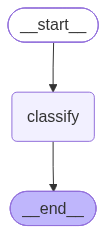

In [9]:
wrkflow

In [13]:
from llama_index.core import SimpleDirectoryReader

In [14]:
documents = SimpleDirectoryReader(input_files=[r"../data/63d00cdb-f5fb-4d86-9a8e-4cea460455f1.md"]).load_data()
text = documents[0].text
new_job_id = str(uuid.uuid4())
initial_state = PipelineState(
    job_id=new_job_id,
    raw_text=text,
    metadata=None,
    knowledge_base=None,
    validation_errors=[],
    current_stage="Initialized"
)

In [15]:
def educational_classification_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    
    app_logger.info(
        "Starting Educational Classification",
        extra={"extra_info": {"job_id": job_id, "stage": 2}}
    )
    try:
        result: EducationalMetadata = knowledge_extractor.extract_metadata(
            raw_markdown=state["raw_text"],
            job_id=job_id
        )
        return {
            "metadata": result,
            "current_stage": "Stage 2 Complete"
        }
    except Exception as e:
        app_logger.error(
            f"Classification failed: {str(e)}", 
            extra={"extra_info": {"job_id": job_id}}
        )    
    
educational_classfication_node = educational_classification_node(PipelineState)

2026-08-01 18:23:24,347 | INFO     | TeacherAI | Starting Educational Classification
2026-08-01 18:23:24,384 | INFO     | TeacherAI | Starting Stage 2: Extracting Educational Metadata
2026-08-01 18:23:24,393 | INFO     | TeacherAI | Sending request to LLM Gateway


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 1151, in emit
    msg = self.format(record)
  File "C:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\logging\__init__.py", line 999, in format
    return fmt.format(record)
           ~~~~~~~~~~^^^^^^^^
  File "d:\GyanPrakash-Intern\GyanSetu\app\core\logger.py", line 27, in format
    return json.dumps(log_obj)
           ~~~~~~~~~~^^^^^^^^^
  File "C:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\json\__init__.py", line 231, in dumps
    return _default_encoder.encode(obj)
           ~~~~~~~~~~~~~~~~~~~~~~~^^^^^
  File "C:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\json\encoder.py", line 200, in encode
    chunks = self.iterencode(o, _one_shot=True)
  File "C:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\json\encoder.py", line 261, in iterencode
    return _iterencode(o, 0)
  File "C:\Users\pr

In [16]:
educational_classfication_node

{'metadata': EducationalMetadata(subject='General', grade='Class 10', difficulty='Intermediate', topic='Pipeline State Management', chapter='Computer Science Fundamentals', category='STEM', language='English'),
 'current_stage': 'Stage 2 Complete'}

In [35]:
import uuid
from core.logger import app_logger
from models.schemas import EducationalMetadata, ExtractedKnowledge
from infrastructure.llm_gateway import llm_gateway
from core.exceptions import ExtractionError
from core.prompts import Prompts

In [ ]:
def extract_knowledge(raw_markdown: str, metadata: EducationalMetadata, job_id: str = "dsaflj232") -> ExtractedKnowledge:
    job_id = job_id or f"know_{uuid.uuid4().hex[:8]}"
    
    app_logger.info(
        "Starting Stage 3: Extracting Knowledge Base",
        extra={"extra_info": {"job_id": job_id}}
    )
    
    messages = Prompts.Extraction.KNOWLEDGE_EXTRACTION_TEMPLATE.invoke({
        "text": raw_markdown,
        "grade": metadata.grade,
        "difficulty": metadata.difficulty,
        "subject": metadata.subject
    })
    
    try:
        return llm_gateway.generate_structured(
            prompt=messages,
            response_model=ExtractedKnowledge,
            job_id=job_id
        )
    except Exception as e:
        app_logger.error(
            f"Stage 3 Failed: {str(e)}",
            extra={"extra_info": {"job_id": job_id}}
        )
        raise ExtractionError(f"Failed to extract knowledge base: {str(e)}")

# extract_knowledge(text, metadata)

In [39]:
extract_knowledge(text, educational_classfication_node["metadata"])

2026-08-01 18:27:48,121 | INFO     | TeacherAI | Starting Stage 3: Extracting Knowledge Base
2026-08-01 18:27:48,125 | INFO     | TeacherAI | Sending request to LLM Gateway
2026-08-01 18:27:48,653 | ERROR    | TeacherAI | Fatal LLM Error: Error code: 400 - {'error': {'message': "Invalid schema for response_format 'ExtractedKnowledge': In context=(), 'required' is required to be supplied and to be an array including every key in properties. Extra required key 'definitions' supplied.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': None}}
2026-08-01 18:27:48,654 | ERROR    | TeacherAI | Stage 3 Failed: Failed to generate structured data from LLM


d:\GyanPrakash-Intern\GyanSetu\venv\Lib\site-packages\langchain_openai\chat_models\base.py:590: UserWarning: Invalid schema for OpenAI's structured output feature, which is the default method for `with_structured_output` as of langchain-openai==0.3. Specify `method="function_calling"` instead or update your schema. See supported schemas: https://platform.openai.com/docs/guides/structured-outputs#supported-schemas
  warnings.warn(message)


ExtractionError: Failed to extract knowledge base: Failed to generate structured data from LLM

In [27]:
educational_classfication_node["metadata"]

EducationalMetadata(subject='General', grade='Class 10', difficulty='Intermediate', topic='Pipeline State Management', chapter='Computer Science Fundamentals', category='STEM', language='English')